# Pipeline JRAIGS a partir de labels.csv

Ce notebook combine les etapes principales a partir de `datasets/jraigs_prepared/labels.csv` :
Lancer prepare_jraigs.py pour prendre seulement les données directement doublements approuvées et les colonnes fusionnées

In [1]:
from __future__ import annotations

import os
import shutil
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

In [2]:
PROJECT_ROOT = Path.cwd()
INPUT_CSV = PROJECT_ROOT / "datasets" / "jraigs_prepared" / "labels.csv"
SUBSETS_ROOT = PROJECT_ROOT / "datasets" / "jraigs_subsets"
OUTPUT_ROOT = PROJECT_ROOT / "outputs" / "eda"
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

if not INPUT_CSV.exists():
    raise FileNotFoundError(f"Fichier introuvable: {INPUT_CSV}")

df = pd.read_csv(INPUT_CSV, low_memory=False)
print(f"Loaded: {INPUT_CSV}")
print(f"Rows={len(df)} | Cols={len(df.columns)}")
df.head(3)


Loaded: /raid/home/students/hawky_luc/P-le-Projet-Zenkolab/datasets/jraigs_prepared/labels.csv
Rows=93011 | Cols=29


,Eye ID,Final Label,Fellow Eye ID,Age,G1 ANRS,G1 ANRI,G1 RNFLDS,G1 RNFLDI,G1 BCLVS,G1 BCLVI,...,G2 BCLVI,G2 NVT,G2 DH,G2 LD,G2 LC,source_image,kept_image,brightness,color_mean_rgb,blur_score
0,TRAIN000000,NRG,TRAIN081848,48.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,/raid/home/students/hawky_luc/P-le-Projet-Zenk...,/raid/home/students/hawky_luc/P-le-Projet-Zenk...,56.604061,"77.22,57.34,35.26",798.552246
1,TRAIN000001,NRG,TRAIN018312,29.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,/raid/home/students/hawky_luc/P-le-Projet-Zenk...,/raid/home/students/hawky_luc/P-le-Projet-Zenk...,65.608231,"91.38,61.84,43.60",139.163086
2,TRAIN000002,NRG,TRAIN083822,61.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,/raid/home/students/hawky_luc/P-le-Projet-Zenk...,/raid/home/students/hawky_luc/P-le-Projet-Zenk...,48.810745,"53.28,47.73,45.42",386.181641


# Subsets selon la caractéristique de la maladie

In [6]:
CHARACTERISTICS = [
    "ANRS", "ANRI", "RNFLDS", "RNFLDI",
    "BCLVS", "BCLVI", "NVT", "DH", "LD", "LC",
]

NON_GLAUCOMA_LABELS = {"NRG", "0", "NEGATIVE", "NORMAL", "NON_GLAUCOMA", "NON-GLAUCOMA", "NO_GLAUCOMA"}

def link_or_copy(src: str | None, dst: Path) -> bool:
    if not src:
        return False
    src_path = Path(src)
    if not src_path.exists():
        return False
    dst.parent.mkdir(parents=True, exist_ok=True)
    if not dst.exists():
        try:
            os.link(src_path, dst)
        except OSError:
            shutil.copy2(src_path, dst)
    return True

def write_subset_with_images(subset: pd.DataFrame, output_dir: Path) -> int:
    images_dir = output_dir / "images"
    images_dir.mkdir(parents=True, exist_ok=True)

    subset_images: list[str | None] = []
    for src in subset.get("kept_image", [None] * len(subset)):
        dst_name = Path(src).name if src else None
        dst = images_dir / dst_name if dst_name else None
        if dst and link_or_copy(src, dst):
            subset_images.append(str(dst))
        else:
            subset_images.append(None)

    out = subset.copy()
    out["subset_image"] = subset_images
    out.to_csv(output_dir / "labels.csv", index=False)
    return len(out)

def parse_color_triplet(value: object) -> tuple[float, float, float] | None:
    if pd.isna(value):
        return None
    text = str(value).strip()
    if not text:
        return None
    parts = text.split(",")
    if len(parts) != 3:
        return None
    try:
        return float(parts[0]), float(parts[1]), float(parts[2])
    except ValueError:
        return None



In [ ]:
# Creation des subsets
creation_log = []

for char in CHARACTERISTICS:
    g1_col = f"G1 {char}"
    g2_col = f"G2 {char}"
    if g1_col in df.columns and g2_col in df.columns:
        subset = df[(df[g1_col] == 1) & (df[g2_col] == 1)].copy()
        out_dir = SUBSETS_ROOT / char
        n = write_subset_with_images(subset, out_dir)
        creation_log.append((char, n, out_dir))

label_col = "Final Label" if "Final Label" in df.columns else None
if label_col is not None:
    labels = df[label_col].astype(str).str.strip().str.upper()
    non_glaucoma_df = df[labels.isin(NON_GLAUCOMA_LABELS)].copy()
    out_dir = SUBSETS_ROOT / "non_glaucoma"
    n = write_subset_with_images(non_glaucoma_df, out_dir)
    creation_log.append(("non_glaucoma", n, out_dir))

pd.DataFrame(creation_log, columns=["subset", "rows", "path"]).sort_values("subset")

## Statistiques et répartitions des subsets

In [ ]:
# Stats "illness" (RG) vs non-illness (NRG)
#print(df.head)

# 1) Global distribution from full dataframe
label_counts = (
    df["Final Label"]
    .astype(str)
    .str.strip()
    .str.upper()
    .value_counts()
)

#print(label_counts)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Global bar
axes[0].bar(label_counts.index, label_counts.values, color=["#264653", "#E76F51"])
axes[0].set_title("Global label distribution")
axes[0].set_xlabel("Label")
axes[0].set_ylabel("Rows")

# Add percentage annotations on global bar
total_global = label_counts.sum()
for i, (label, count) in enumerate(label_counts.items()):
    pct = count / total_global * 100
    axes[0].text(i, count + total_global * 0.01, f"{pct:.1f}%", ha="center", va="bottom", fontsize=10)

illness_plot = df.copy()
illness_plot = illness_plot[
    illness_plot["Final Label"].astype(str).str.strip().str.upper().eq("RG")
].copy()

sub_illness_counts = pd.Series(
    {
        char: (
            (illness_plot[f"G1 {char}"] == 1) & (illness_plot[f"G2 {char}"] == 1)
        ).sum()
        for char in CHARACTERISTICS
        if f"G1 {char}" in illness_plot.columns and f"G2 {char}" in illness_plot.columns
    }
).sort_values(ascending=False)

axes[1].bar(sub_illness_counts.index, sub_illness_counts.values, color="#2A9D8F")
axes[1].set_title("Sub-illness distribution within RG")
axes[1].set_xlabel("Characteristic")
axes[1].set_ylabel("Rows")
axes[1].tick_params(axis="x", rotation=45)

total_rg = len(illness_plot)
for i, v in enumerate(sub_illness_counts.values):
    pct = (v / total_rg * 100) if total_rg else 0
    axes[1].text(i, v + max(1, sub_illness_counts.max() * 0.01), f"{pct:.1f}%", ha="center", fontsize=9)
axes[1].bar

plt.tight_layout()
plt.show()

## Histogrammes luminosité et couleurs

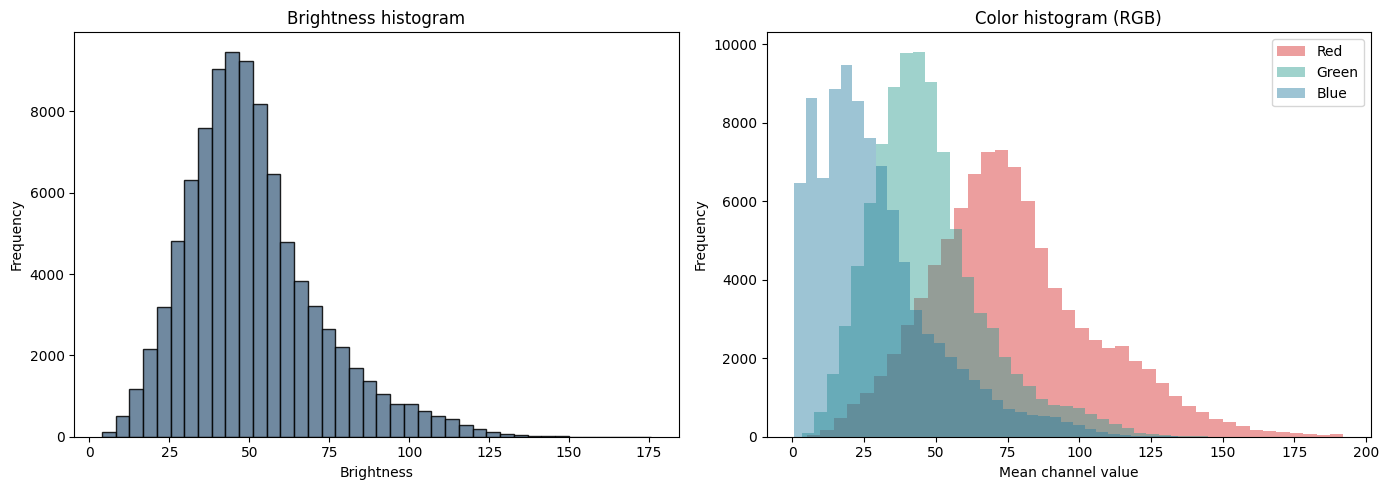

In [7]:
# Histogrammes globaux: brightness + RGB
b = pd.to_numeric(df.get("brightness"), errors="coerce").dropna()
rgb = df.get("color_mean_rgb", pd.Series([None] * len(df))).apply(parse_color_triplet)
rgb_valid = rgb[rgb.notna()]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Brightness
axes[0].hist(b, bins=40, color="#577590", edgecolor="black", alpha=0.85)
axes[0].set_title("Brightness histogram")
axes[0].set_xlabel("Brightness")
axes[0].set_ylabel("Frequency")

# RGB
if not rgb_valid.empty:
    rgb_df = pd.DataFrame(rgb_valid.tolist(), columns=["red", "green", "blue"])
    axes[1].hist(rgb_df["red"], bins=40, color="#D62828", alpha=0.45, label="Red")
    axes[1].hist(rgb_df["green"], bins=40, color="#2A9D8F", alpha=0.45, label="Green")
    axes[1].hist(rgb_df["blue"], bins=40, color="#277DA1", alpha=0.45, label="Blue")
    axes[1].legend()
else:
    axes[1].text(0.5, 0.5, "No valid RGB values", ha="center", va="center")
    axes[1].set_xlim(0, 1)
    axes[1].set_ylim(0, 1)

axes[1].set_title("Color histogram (RGB)")
axes[1].set_xlabel("Mean channel value")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

### Qualité des images selon la luminosité

In [ ]:
# Show 5 random images per brightness interval of width 10 (capped, memory-safe)
brightness_num = pd.to_numeric(df.get("brightness"), errors="coerce")
image_col = "kept_image" if "kept_image" in df.columns else "source_image"

valid = df[brightness_num.notna()].copy()
valid["brightness_num"] = brightness_num[brightness_num.notna()]

# Keep only rows with existing image paths (compute once, not per interval)
valid = valid[
    valid[image_col].notna()
    & valid[image_col].astype(str).str.strip().ne("")
    & valid[image_col].apply(lambda p: Path(str(p)).exists())
] .copy()

if valid.empty:
    print("No valid brightness values or image paths found.")
else:
    max_intervals = 12
    interval_starts = sorted(((valid["brightness_num"] // 10) * 10).astype(int).unique())

    if len(interval_starts) > max_intervals:
        print(f"Too many brightness intervals ({len(interval_starts)}). Showing first {max_intervals} intervals only.")
        interval_starts = interval_starts[:max_intervals]

    for low in interval_starts:
        high = low + 10
        bucket = valid[(valid["brightness_num"] >= low) & (valid["brightness_num"] < high)].copy()

        if bucket.empty:
            continue

        sample_n = min(5, len(bucket))
        sample = bucket.sample(n=sample_n, random_state=42)

        fig, axes = plt.subplots(1, sample_n, figsize=(3.6 * sample_n, 4))
        fig.suptitle(f"Brightness interval [{low}, {high}) - {sample_n} random image(s)", fontsize=12)

        if sample_n == 1:
            axes = [axes]

        for ax in axes:
            ax.axis("off")

        for j, (_, row) in enumerate(sample.iterrows()):
            img_path = Path(str(row[image_col]))
            try:
                img = plt.imread(img_path)
                axes[j].imshow(img)
                axes[j].set_title(f"{row['brightness_num']:.2f}", fontsize=10)
            except Exception:
                axes[j].text(0.5, 0.5, f"Load error\n{img_path.name}", ha="center", va="center", fontsize=8)
                axes[j].set_title("error", fontsize=10)

        plt.tight_layout()
        plt.show()
        plt.close(fig)

#### On retire une partie selon la luminosité

In [3]:
df_current= df.copy()

df_current=df_current[df_current["brightness"].notna() & (df_current["brightness"] <110 ) & (df_current["brightness"] >30 )]

print(f"Proportion removed: {1-(len(df_current)/len(df))}")
print(f"Number of rows in df_current: {len(df_current)}")

print(df_current["brightness"].describe())
print(df_current.head())

Proportion removed: 0.14790723677844553
Number of rows in df_current: 79254
count    79254.000000
mean        54.003299
std         16.953873
min         30.001268
25%         41.342628
50%         50.403885
75%         62.847891
max        109.988823
Name: brightness, dtype: float64
        Eye ID Final Label Fellow Eye ID   Age  G1 ANRS  G1 ANRI  G1 RNFLDS  \
0  TRAIN000000         NRG   TRAIN081848  48.0      0.0      0.0        0.0   
1  TRAIN000001         NRG   TRAIN018312  29.0      0.0      0.0        0.0   
2  TRAIN000002         NRG   TRAIN083822  61.0      0.0      0.0        0.0   
4  TRAIN000004         NRG   TRAIN099283  48.0      0.0      0.0        0.0   
5  TRAIN000005         NRG   TRAIN062790  67.0      0.0      0.0        0.0   

   G1 RNFLDI  G1 BCLVS  G1 BCLVI  ...  G2 BCLVI  G2 NVT  G2 DH  G2 LD  G2 LC  \
0        0.0       0.0       0.0  ...       0.0     0.0    0.0    0.0    0.0   
1        0.0       0.0       0.0  ...       0.0     0.0    0.0    0.0    0.0   


### Qualité des images selon la couleur

In [ ]:
# Show 5 random images per color interval (width = 10) using mean RGB value (capped, memory-safe)

image_col = "kept_image" if "kept_image" in df_current.columns else "source_image"

rgb_series = df_current.get("color_mean_rgb", pd.Series([None] * len(df_current))).apply(parse_color_triplet)
rgb_df = pd.DataFrame(rgb_series.tolist(), columns=["red", "green", "blue"], index=df_current.index)
df_current = df_current.join(rgb_df)

valid = df_current[
    df_current[image_col].notna()
    & df_current[image_col].astype(str).str.strip().ne("")
    & df_current[image_col].apply(lambda p: Path(str(p)).exists())
] .copy()

max_intervals = 12

# Separate visualization by RGB channel
for channel, color in [("red", "#D62828"), ("green", "#2A9D8F"), ("blue", "#277DA1")]:
    chan_valid = valid[valid[channel].notna()].copy()
    if chan_valid.empty:
        print(f"No valid values for {channel}.")
        continue

    interval_starts = sorted(((chan_valid[channel] // 10) * 10).astype(int).unique())
    if len(interval_starts) > max_intervals:
        print(f"{channel}: too many intervals ({len(interval_starts)}). Showing first {max_intervals} intervals only.")
        interval_starts = interval_starts[:max_intervals]

    for low in interval_starts:
        high = low + 10
        bucket = chan_valid[(chan_valid[channel] >= low) & (chan_valid[channel] < high)]

        if bucket.empty:
            continue

        sample_n = min(5, len(bucket))
        sample = bucket.sample(n=sample_n, random_state=42)

        fig, axes = plt.subplots(1, sample_n, figsize=(3.6 * sample_n, 4))
        fig.suptitle(f"{channel.upper()} interval [{low}, {high}) - {sample_n} random image(s)", fontsize=12)

        if sample_n == 1:
            axes = [axes]

        for ax in axes:
            ax.axis("off")

        for j, (_, row) in enumerate(sample.iterrows()):
            img_path = Path(str(row[image_col]))
            try:
                img = plt.imread(img_path)
                axes[j].imshow(img)
                axes[j].set_title(f"{row[channel]:.1f}", fontsize=10, color=color)
            except Exception:
                axes[j].text(0.5, 0.5, f"Load error\n{img_path.name}", ha="center", va="center", fontsize=8)
                axes[j].set_title("error", fontsize=10)

        plt.tight_layout()
        plt.show()
        plt.close(fig)

# Keep compatibility with the code below (global mean color)
df_current["color_mean"] = df_current[["red", "green", "blue"]].mean(axis=1, skipna=True)
valid_mean = valid[valid[["red", "green", "blue"]].notna().all(axis=1)].copy()
valid_mean = valid_mean[valid_mean["color_mean"].notna()].copy()

interval_starts = sorted(((valid_mean["color_mean"] // 10) * 10).astype(int).unique())
if len(interval_starts) > max_intervals:
    print(f"color_mean: too many intervals ({len(interval_starts)}). Showing first {max_intervals} intervals only.")
    interval_starts = interval_starts[:max_intervals]

for low in interval_starts:
    high = low + 10
    bucket = valid_mean[(valid_mean["color_mean"] >= low) & (valid_mean["color_mean"] < high)]

    if bucket.empty:
        continue

    sample_n = min(5, len(bucket))
    sample = bucket.sample(n=sample_n, random_state=42)

    fig, axes = plt.subplots(1, sample_n, figsize=(3.6 * sample_n, 4))
    fig.suptitle(f"Color mean interval [{low}, {high}) - {sample_n} random image(s)", fontsize=12)

    if sample_n == 1:
        axes = [axes]

    for ax in axes:
        ax.axis("off")

    for j, (_, row) in enumerate(sample.iterrows()):
        img_path = Path(str(row[image_col]))
        try:
            img = plt.imread(img_path)
            axes[j].imshow(img)
            axes[j].set_title(f"{row['color_mean']:.1f}", fontsize=10)
        except Exception:
            axes[j].text(0.5, 0.5, f"Load error\n{img_path.name}", ha="center", va="center", fontsize=8)
            axes[j].set_title("error", fontsize=10)

    plt.tight_layout()
    plt.show()
    plt.close(fig)

#### On retire une partie à nouveau selon la couleur

In [8]:
# Filter df_current based on RGB channel ranges
before = len(df_current)

# red/green/blue are extracted from color_mean_rgb (R,G,B)
rgb = df_current["color_mean_rgb"].apply(parse_color_triplet)

df_current = df_current.assign(
    red=rgb.apply(lambda t: t[0] if t is not None else pd.NA),
    green=rgb.apply(lambda t: t[1] if t is not None else pd.NA),
    blue=rgb.apply(lambda t: t[2] if t is not None else pd.NA),
)

df_current = df_current[
    df_current["red"].between(20, 170) &
    df_current["green"].between(20, 100) &
    (df_current["blue"] <= 100)
].copy()

after = len(df_current)
print(f"Rows removed: {before - after} ({(before - after) / before * 100:.1f}%)")
print(f"Rows remaining: {after}")

Rows removed: 1217 (1.5%)
Rows remaining: 78037


In [ ]:
# Detect likely saturated images using color_mean_rgb (heuristic from channel means)
base_df = df_current.copy() if "df_current" in globals() else df.copy()

image_col = "kept_image" if "kept_image" in base_df.columns else "source_image"
rgb_series = base_df.get("color_mean_rgb", pd.Series([None] * len(base_df))).apply(parse_color_triplet)
parsed_rgb_df = pd.DataFrame(rgb_series.tolist(), columns=["red", "green", "blue"], index=base_df.index)

sat_df = base_df.copy()
for c in ["red", "green", "blue"]:
    if c in sat_df.columns:
        sat_df[c] = pd.to_numeric(sat_df[c], errors="coerce")
    else:
        sat_df[c] = parsed_rgb_df[c]

sat_df = sat_df[sat_df[["red", "green", "blue"]].notna().all(axis=1)].copy()

if sat_df.empty:
    print("No valid RGB means found.")
else:
    sat_df["rgb_mean"] = sat_df[["red", "green", "blue"]].mean(axis=1)
    sat_df["rgb_max"] = sat_df[["red", "green", "blue"]].max(axis=1)
    sat_df["rgb_min"] = sat_df[["red", "green", "blue"]].min(axis=1)
    sat_df["channel_spread"] = sat_df["rgb_max"] - sat_df["rgb_min"]
    sat_df["spread_ratio"] = sat_df["channel_spread"] / (sat_df["rgb_mean"] + 1e-6)

    sat_df["near_clip"] = ((sat_df["rgb_max"] >= 245) | (sat_df["rgb_min"] <= 10)).astype(int)
    sat_df["sat_score"] = sat_df["spread_ratio"] + 0.35 * sat_df["near_clip"]

    sat_threshold = sat_df["sat_score"].quantile(0.95)
    saturated = sat_df[sat_df["sat_score"] >= sat_threshold].sort_values("sat_score", ascending=False).copy()

    print(f"Rows analyzed: {len(sat_df)}")
    print(f"Likely saturated rows (top 5%): {len(saturated)}")
    print(f"Threshold sat_score >= {sat_threshold:.3f}")

    display_cols = ["red", "green", "blue", "sat_score", "channel_spread", "spread_ratio"]
    print(saturated[display_cols].head(10))

    show_df = saturated[
        saturated[image_col].notna()
        & saturated[image_col].astype(str).str.strip().ne("")
        & saturated[image_col].apply(lambda p: Path(str(p)).exists())
    ].head(5)

    if show_df.empty:
        print("No image paths available to preview.")
    else:
        fig, axes = plt.subplots(1, 5, figsize=(18, 4))
        for ax in axes:
            ax.axis("off")

        for i, (_, row) in enumerate(show_df.iterrows()):
            img_path = Path(str(row[image_col]))
            try:
                img = plt.imread(img_path)
                axes[i].imshow(img)
                axes[i].set_title(
                    f"score={row['sat_score']:.2f}\nR{row['red']:.0f} G{row['green']:.0f} B{row['blue']:.0f}",
                    fontsize=9,
                )
            except Exception:
                axes[i].text(0.5, 0.5, f"Load error\n{img_path.name}", ha="center", va="center", fontsize=8)
                axes[i].set_title("error", fontsize=9)

        plt.tight_layout()
        plt.show()
        plt.close(fig)

## Lancer add_blur_metrics.py pour ajouter la colonne netteté 

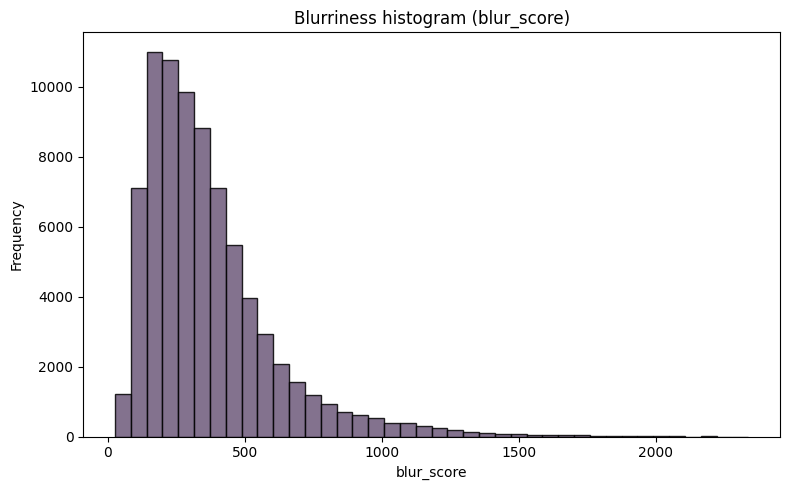

In [9]:
# Histogram of blurriness (blur_score)
base_df = df_current if "df_current" in globals() else df
blur = pd.to_numeric(base_df.get("blur_score"), errors="coerce").dropna()

if blur.empty:
    print("No valid blur_score values found.")
else:
    plt.figure(figsize=(8, 5))
    plt.hist(blur, bins=40, color="#6D597A", edgecolor="black", alpha=0.85)
    plt.title("Blurriness histogram (blur_score)")
    plt.xlabel("blur_score")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

In [ ]:
# Show random images per blurriness interval (width = 100) with memory-safe plotting
base_df = df_current if "df_current" in globals() else df
image_col = "kept_image" if "kept_image" in base_df.columns else "source_image"

blur_num = pd.to_numeric(base_df.get("blur_score"), errors="coerce")
valid_blur = base_df[blur_num.notna()].copy()
valid_blur["blur_num"] = blur_num[blur_num.notna()]

# Keep only rows with existing image paths
valid_blur = valid_blur[
    valid_blur[image_col].notna()
    & valid_blur[image_col].astype(str).str.strip().ne("")
    & valid_blur[image_col].apply(lambda p: Path(str(p)).exists())
] .copy()

if valid_blur.empty:
    print("No valid blur_score values or image paths found.")
else:
    max_intervals = 12
    interval_starts = sorted(((valid_blur["blur_num"] // 100) * 100).astype(int).unique())

    if len(interval_starts) > max_intervals:
        print(f"Too many blur intervals ({len(interval_starts)}). Showing first {max_intervals} intervals only.")
        interval_starts = interval_starts[:max_intervals]

    for low in interval_starts:
        high = low + 100
        bucket = valid_blur[(valid_blur["blur_num"] >= low) & (valid_blur["blur_num"] < high)]

        if bucket.empty:
            continue

        sample_n = min(5, len(bucket))
        sample = bucket.sample(n=sample_n, random_state=42)

        fig, axes = plt.subplots(1, sample_n, figsize=(3.6 * sample_n, 4))
        fig.suptitle(f"Blur interval [{low}, {high}) - {sample_n} random image(s)", fontsize=12)

        if sample_n == 1:
            axes = [axes]

        for ax in axes:
            ax.axis("off")

        for j, (_, row) in enumerate(sample.iterrows()):
            img_path = Path(str(row[image_col]))
            try:
                img = plt.imread(img_path)
                axes[j].imshow(img)
                axes[j].set_title(f"{row['blur_num']:.1f}", fontsize=10)
            except Exception:
                axes[j].text(0.5, 0.5, f"Load error\n{img_path.name}", ha="center", va="center", fontsize=8)
                axes[j].set_title("error", fontsize=10)

        plt.tight_layout()
        plt.show()
        plt.close(fig)

### On retire les blur trop élevés

In [10]:
before = len(df_current)

df_current=df_current[df_current["blur_score"].notna() & (df_current["blur_score"] <1100 ) ]

print(f"Proportion removed: {1-(len(df_current)/before)}")
print(f"Number of rows in df_current: {len(df_current)}")

print(df_current["blur_score"].describe())
print(df_current.head())

Proportion removed: 0.01960608429334798
Number of rows in df_current: 76507
count    76507.000000
mean       346.736925
std        199.088925
min         25.341797
25%        197.746582
50%        304.147949
75%        444.718506
max       1099.825684
Name: blur_score, dtype: float64
        Eye ID Final Label Fellow Eye ID   Age  G1 ANRS  G1 ANRI  G1 RNFLDS  \
0  TRAIN000000         NRG   TRAIN081848  48.0      0.0      0.0        0.0   
1  TRAIN000001         NRG   TRAIN018312  29.0      0.0      0.0        0.0   
2  TRAIN000002         NRG   TRAIN083822  61.0      0.0      0.0        0.0   
4  TRAIN000004         NRG   TRAIN099283  48.0      0.0      0.0        0.0   
5  TRAIN000005         NRG   TRAIN062790  67.0      0.0      0.0        0.0   

   G1 RNFLDI  G1 BCLVS  G1 BCLVI  ...  G2 LD  G2 LC  \
0        0.0       0.0       0.0  ...    0.0    0.0   
1        0.0       0.0       0.0  ...    0.0    0.0   
2        0.0       0.0       0.0  ...    0.0    0.0   
4        0.0       0

In [11]:
# Save filtered dataframe only if file does not already exist
output_csv = PROJECT_ROOT / "datasets" / "jraigs_prepared" / "lum_color_blur_filtered.csv"

if output_csv.exists():
    print(f"File already exists, not overwritten: {output_csv}")
else:
    output_csv.parent.mkdir(parents=True, exist_ok=True)
    df_current.to_csv(output_csv, index=False)
    print(f"Saved: {output_csv}")

# Give characteristics of df_current
print(f"Rows: {len(df_current)} | Cols: {len(df_current.columns)}")

if "Final Label" in df_current.columns:
    print("\nFinal Label distribution:")
    print(df_current["Final Label"].astype(str).str.strip().str.upper().value_counts())

char_stats = []
for char in CHARACTERISTICS:
    g1_col, g2_col = f"G1 {char}", f"G2 {char}"
    if g1_col in df_current.columns and g2_col in df_current.columns:
        n = ((df_current[g1_col] == 1) & (df_current[g2_col] == 1)).sum()
        char_stats.append((char, int(n)))

if char_stats:
    char_df = pd.DataFrame(char_stats, columns=["characteristic", "rows"]).sort_values("rows", ascending=False)
    print("\nCharacteristic counts (G1=1 and G2=1):")
    print(char_df.to_string(index=False))

Saved: /raid/home/students/hawky_luc/P-le-Projet-Zenkolab/datasets/jraigs_prepared/lum_color_blur_filtered.csv
Rows: 76507 | Cols: 32

Final Label distribution:
Final Label
NRG    74722
RG      1785
Name: count, dtype: int64

Characteristic counts (G1=1 and G2=1):
characteristic  rows
          ANRI  1199
          ANRS  1084
            LC   486
            LD   355
           NVT   265
         BCLVI   148
         BCLVS   117
        RNFLDI    96
        RNFLDS    82
            DH    37
